[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/ENM5320-2026/blob/main/scikitFEM_tut/FEM_Hackathon_Poisson2D.ipynb)

# FEM Hackathon: 2D Poisson Equation on a Complex Geometry

In this hackathon we will use **scikit-fem** — a lightweight finite element library — to solve the Poisson equation

$$-\Delta u = f \quad \text{in } \Omega$$

on the domain $\Omega = [0,1]^2 \setminus B_r(0.5, 0.5)$ — a unit square with a circular hole of radius $r = 0.15$ centered at $(0.5, 0.5)$.

**Outline:**
1. **Mesh generation** — Build a triangular mesh of the domain using `pygmsh` (a Python interface to `gmsh`)
2. **Warmup** — Solve the Poisson equation with $f = 1$ and homogeneous Dirichlet BCs (all code provided)
3. **Your task** — Set up a *manufactured solution* convergence study to verify the theoretical error estimates:
   - $\|u - u_h\|_{L^2} = O(h^2)$
   - $|u - u_h|_{H^1} = O(h)$

**Prerequisites:** Lecture 14 (variational formulation, Lax–Milgram) and Lecture 15 (Galerkin projection, quasi-optimality).

**References.** You'll find the following links from scikit-fem to be useful references:
- [Extended tutorial](https://scikit-fem.readthedocs.io/en/stable/extended.html)
- [Getting started](https://scikit-fem.readthedocs.io/en/stable/gettingstarted.html)
- [How to guide](https://scikit-fem.readthedocs.io/en/stable/howto.html)

## 0. Setup

In [1]:
# Install dependencies (run once)
import sys, subprocess
if 'google.colab' in sys.modules:
    # Colab needs system libraries for gmsh's OpenCASCADE kernel
    subprocess.check_call(['apt-get', 'install', '-qq', '-y', 'libgl1-mesa-glx', 'libglu1-mesa'],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
%pip install scikit-fem pygmsh meshio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 19.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

import pygmsh
from skfem import *
from skfem.helpers import dot, grad
from skfem.visuals.matplotlib import plot as fem_plot, draw as fem_draw

---
## 1. Mesh Generation

We use **pygmsh** (a Python wrapper around the `gmsh` mesher) to create a triangulation of our domain.

The geometry is constructed via the OpenCASCADE kernel:
1. Create a rectangle $[0,1]^2$
2. Create a disk $B_{0.15}(0.5, 0.5)$
3. Take their Boolean difference

The parameter `characteristic_length_max` controls the maximum element size $h_{\max}$.

In [3]:
def make_mesh(h_max=0.05):
    """Generate a triangular mesh of the unit square with a circular hole."""
    with pygmsh.occ.Geometry() as geom:
        geom.characteristic_length_max = h_max
        rect = geom.add_rectangle([0.0, 0.0, 0.0], 1.0, 1.0)
        disk = geom.add_disk([0.5, 0.5], 0.15)
        geom.boolean_difference(rect, disk)
        msh = geom.generate_mesh(dim=2)
    # Convert meshio mesh -> scikit-fem MeshTri
    return MeshTri(
        msh.points[:, :2].T,          # node coordinates (2 x n_nodes)
        msh.cells_dict['triangle'].T   # element connectivity (3 x n_elements)
    )

Nodes: 515,  Elements: 931


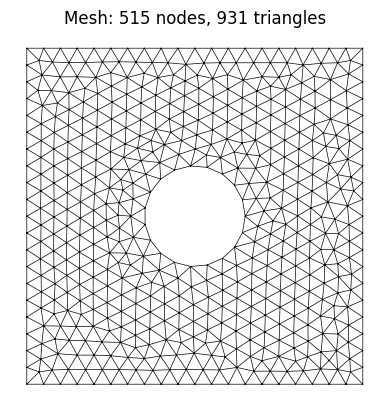

In [4]:
# Generate a mesh and visualize it
mesh = make_mesh(h_max=0.05)
print(f"Nodes: {mesh.p.shape[1]},  Elements: {mesh.t.shape[1]}")

ax = fem_draw(mesh)
ax.set_title(f"Mesh: {mesh.p.shape[1]} nodes, {mesh.t.shape[1]} triangles")
ax.set_aspect('equal')
plt.show()

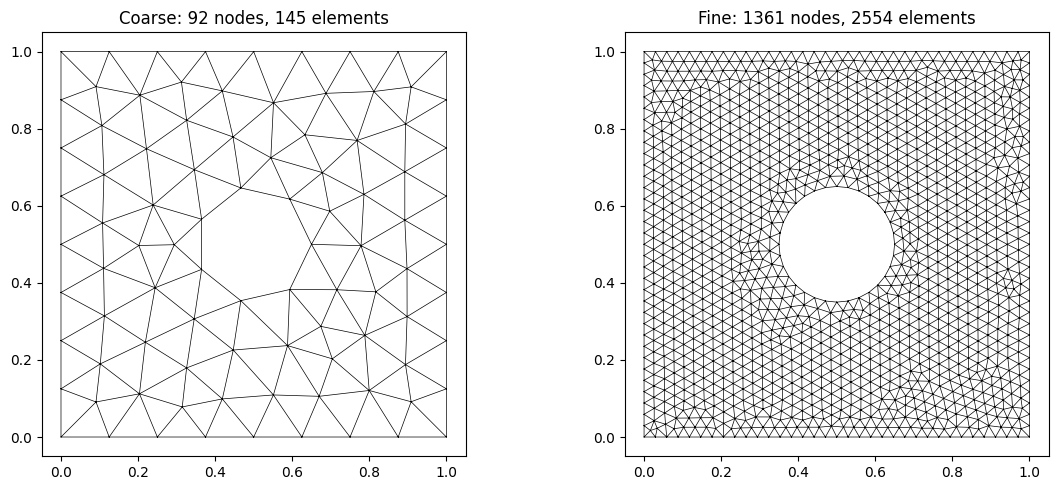

In [5]:
# Compare coarse vs fine meshes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, h, label in zip(axes, [0.15, 0.03], ['Coarse', 'Fine']):
    m = make_mesh(h_max=h)
    fem_draw(m, ax=ax)
    ax.set_title(f"{label}: {m.p.shape[1]} nodes, {m.t.shape[1]} elements")
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 2. Finite Element Space

Recall from Lecture 14: we seek $u_h \in V_h \subset H^1_0(\Omega)$ where $V_h$ is spanned by **piecewise linear basis functions** $\{\phi_i\}$ on the triangulation.

Each basis function $\phi_i$ is the "hat function" that equals 1 at node $i$ and 0 at all other nodes.

In scikit-fem:
- `ElementTriP1()` — piecewise linear elements on triangles (P1)
- `Basis(mesh, element)` — pairs the mesh with the element type and sets up quadrature rules for integration

In [6]:
element = ElementTriP1()
basis = Basis(mesh, element)
print(f"DOFs (degrees of freedom): {basis.N}")
print(f"Quadrature points per element: {basis.X.shape[-1]}")

DOFs (degrees of freedom): 515
Quadrature points per element: 3


---
## 3. Defining Bilinear and Linear Forms

The Galerkin discretization of $-\Delta u = f$ reads: find $u_h \in V_h$ such that

$$a(u_h, v_h) = \ell(v_h) \quad \forall \, v_h \in V_h$$

where

$$a(u, v) = \int_\Omega \nabla u \cdot \nabla v \, dx, \qquad \ell(v) = \int_\Omega f \, v \, dx$$

This leads to the linear system $K \mathbf{u} = \mathbf{b}$ where

$$K_{ij} = \int_\Omega \nabla \phi_i \cdot \nabla \phi_j \, dx, \qquad b_i = \int_\Omega f \, \phi_i \, dx$$

### scikit-fem syntax

**Bilinear form** — decorate a function that takes `(u, v, w)` and returns the integrand:
```python
@BilinearForm
def stiffness(u, v, w):
    return dot(grad(u), grad(v))     #  ∇u · ∇v
```

**Linear form** — decorate a function that takes `(v, w)` and returns the integrand:
```python
@LinearForm
def load(v, w):
    return f(w.x[0], w.x[1]) * v     #  f(x,y) * v
```

Here `w.x[0]` and `w.x[1]` are the physical $x$ and $y$ coordinates at each quadrature point.

**Assemble** — call `.assemble(basis)` to build the sparse matrix / vector:
```python
K = stiffness.assemble(basis)
b = load.assemble(basis)
```

---
## 4. Warmup: Solve with $f = 1$ and Homogeneous Dirichlet BCs

Before the main task, let's verify the pipeline works. We solve

$$-\Delta u = 1 \quad \text{in } \Omega, \qquad u = 0 \quad \text{on } \partial\Omega$$

with zero Dirichlet conditions on **all** boundaries (both the outer square and the inner circle).

In [7]:
# Define forms
@BilinearForm
def stiffness(u, v, w):
    return dot(grad(u), grad(v))

@LinearForm
def unit_load(v, w):
    return 1.0 * v

# Assemble the stiffness matrix and load vector
K = stiffness.assemble(basis)
b = unit_load.assemble(basis)

print(f"Stiffness matrix: {K.shape[0]}x{K.shape[1]}, {K.nnz} nonzeros")
print(f"Load vector: length {b.shape[0]}")

Stiffness matrix: 515x515, 3407 nonzeros
Load vector: length 515


### Boundary conditions

scikit-fem provides `mesh.boundary_nodes()` to get indices of **all** nodes on $\partial\Omega$.

The function `condense(K, b, D=boundary_dofs)` enforces **homogeneous** Dirichlet BCs ($u = 0$) by eliminating the boundary DOFs from the system.

Then `solve(...)` wraps `scipy.sparse.linalg.spsolve`.

In [8]:
# Find all boundary DOFs and solve with u = 0 on boundary
boundary_dofs = mesh.boundary_nodes()
u_h = solve(*condense(K, b, D=boundary_dofs))

print(f"Solution range: [{u_h.min():.6f}, {u_h.max():.6f}]")

Solution range: [0.000000, 0.021862]


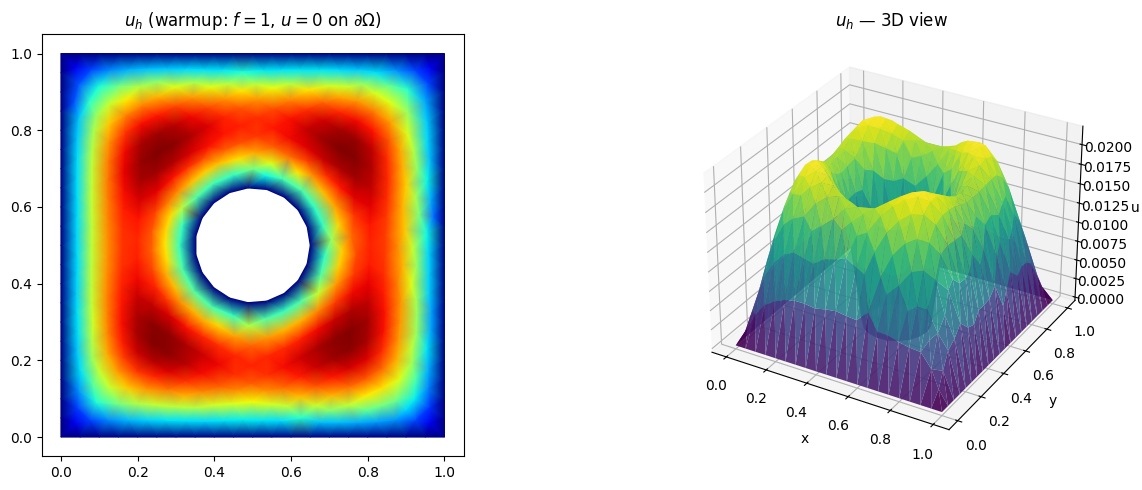

In [9]:
# Visualize the warmup solution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filled contour plot
ax = axes[0]
fem_plot(mesh, u_h, ax=ax, shading='gouraud')
ax.set_title(r'$u_h$ (warmup: $f=1$, $u=0$ on $\partial\Omega$)')
ax.set_aspect('equal')

# 3D surface plot
ax3 = fig.add_subplot(122, projection='3d')
axes[1].remove()
tri = Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)
ax3.plot_trisurf(tri, u_h, cmap='viridis', edgecolor='none', alpha=0.9)
ax3.set_title(r'$u_h$ — 3D view')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('u')

plt.tight_layout()
plt.show()

The warmup solution should be smooth, zero on all boundaries, and positive in the interior — roughly resembling the first eigenfunction of $-\Delta$ on this domain.

---

## 5. Syntax Reference: Boundary Selection and Non-Homogeneous BCs

For the manufactured solution task below, you will need to impose **non-homogeneous** Dirichlet BCs ($u = g$ on $\partial\Omega$ where $g \neq 0$). Here is the syntax you'll need:

### Selecting boundary nodes

```python
# All boundary nodes (both inner circle and outer square)
boundary_dofs = mesh.boundary_nodes()
```

### Getting coordinates of boundary nodes

```python
# x and y coordinates at boundary DOFs
x_bnd = mesh.p[0, boundary_dofs]
y_bnd = mesh.p[1, boundary_dofs]
```

### Solving with non-homogeneous Dirichlet BCs

To impose $u = g(x,y)$ on the boundary, create a vector `u_D` of length `basis.N` with the desired boundary values, and pass it via `x=`:

```python
u_D = np.zeros(basis.N)
u_D[boundary_dofs] = g(x_bnd, y_bnd)    # set desired values at boundary
u_h = solve(*condense(K, b, x=u_D, D=boundary_dofs))
```

## 6. Syntax Reference: Error Computation

scikit-fem provides the `@Functional` decorator for computing integrals that depend on the FE solution. You pass the interpolated solution via `w=basis.interpolate(u_h)`, and inside the function:

- `w.w.value` — values of $u_h$ at quadrature points
- `w.w.grad[0]` — $\partial u_h / \partial x$ at quadrature points  
- `w.w.grad[1]` — $\partial u_h / \partial y$ at quadrature points
- `w.x[0]`, `w.x[1]` — physical coordinates $(x, y)$

**Example: $L^2$ error**
```python
@Functional
def L2_error_sq(w):
    return (w.w.value - u_exact(w.x[0], w.x[1]))**2

L2_err = np.sqrt(L2_error_sq.assemble(basis, w=basis.interpolate(u_h)))
```

**Example: $H^1$ seminorm error**
```python
@Functional
def H1_error_sq(w):
    return (w.w.grad[0] - du_exact_dx(w.x[0], w.x[1]))**2 \
         + (w.w.grad[1] - du_exact_dy(w.x[0], w.x[1]))**2

H1_err = np.sqrt(H1_error_sq.assemble(basis, w=basis.interpolate(u_h)))
```

The helper function below wraps this for convenience — you will use it in the convergence study.

In [10]:
def compute_errors(basis, u_h, u_exact_fn, du_exact_dx_fn, du_exact_dy_fn):
    """Compute L2 and H1 seminorm errors against an exact solution."""
    @Functional
    def L2_error_sq(w):
        return (w.w.value - u_exact_fn(w.x[0], w.x[1]))**2

    @Functional
    def H1_error_sq(w):
        return (w.w.grad[0] - du_exact_dx_fn(w.x[0], w.x[1]))**2 \
             + (w.w.grad[1] - du_exact_dy_fn(w.x[0], w.x[1]))**2

    w_interp = basis.interpolate(u_h)
    L2 = np.sqrt(L2_error_sq.assemble(basis, w=w_interp))
    H1 = np.sqrt(H1_error_sq.assemble(basis, w=w_interp))
    return L2, H1

---
## 7. Your Task: Manufactured Solution Convergence Study

The **method of manufactured solutions** lets us verify convergence rates by choosing a known exact solution and computing the forcing that makes it satisfy the PDE.

### Setup

Choose the exact solution:

$$u_{\text{exact}}(x, y) = \sin(\pi x) \sin(\pi y)$$

**Step 1 — Derive the forcing.** Plug $u_{\text{exact}}$ into $-\Delta u = f$ to get:

$$f(x,y) = -\Delta u_{\text{exact}} = -\left(\frac{\partial^2 u_{\text{exact}}}{\partial x^2} + \frac{\partial^2 u_{\text{exact}}}{\partial y^2}\right) = 2\pi^2 \sin(\pi x)\sin(\pi y)$$

**Step 2 — Boundary conditions.** Note that $u_{\text{exact}} = 0$ on the outer square boundary (since $\sin(0) = \sin(\pi) = 0$), but $u_{\text{exact}} \neq 0$ on the inner circle. Therefore we need **non-homogeneous Dirichlet** BCs:

$$u = u_{\text{exact}} \quad \text{on } \partial\Omega$$

**Step 3 — Expected convergence rates** (from Lecture 15, quasi-optimality + interpolation estimates):
- $\|u - u_h\|_{L^2} = O(h^2)$ for P1 elements
- $|u - u_h|_{H^1} = O(h)$ for P1 elements

### Gradient of the exact solution (needed for $H^1$ error)

$$\frac{\partial u_{\text{exact}}}{\partial x} = \pi \cos(\pi x) \sin(\pi y), \qquad \frac{\partial u_{\text{exact}}}{\partial y} = \pi \sin(\pi x) \cos(\pi y)$$

### TODO 1: Define the exact solution, its gradient, and the forcing

Implement three functions using the formulas above. Each takes arrays `x`, `y` and returns an array of the same shape.

**Syntax reminder** — NumPy trig functions work element-wise on arrays:
```python
np.sin(np.pi * x)     # sin(πx)  
np.cos(np.pi * x)     # cos(πx)
```

In [11]:
def u_exact(x, y):
    """Exact solution: sin(2*pi*x) * sin(2*pi*y)"""
    return np.sin(2 * np.pi * x) * np.sin(2 * np.pi * y)

def du_exact_dx(x, y):
    """Partial derivative du/dx"""
    return 2 * np.pi * np.cos(2 * np.pi * x) * np.sin(2 * np.pi * y)

def du_exact_dy(x, y):
    """Partial derivative du/dy"""
    return 2 * np.pi * np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y)

def f_manufactured(x, y):
    """Forcing: f = -Laplacian(u_exact) = 8*pi^2 * sin(2*pi*x)*sin(2*pi*y)"""
    return 8 * np.pi**2 * np.sin(2 * np.pi * x) * np.sin(2 * np.pi * y)

### TODO 2: Define the linear form with manufactured forcing

Create a `@LinearForm` that uses your `f_manufactured` function as the source term.

**Syntax reminder:**
```python
@LinearForm
def my_load(v, w):
    x, y = w.x[0], w.x[1]
    return some_function(x, y) * v
```

In [12]:
@LinearForm
def manufactured_load(v, w):
    x, y = w.x[0], w.x[1]
    return f_manufactured(x, y) * v

### TODO 3: Solve with non-homogeneous Dirichlet BCs

Assemble the system and solve with $u = u_{\text{exact}}$ imposed on all boundary nodes.

**Steps:**
1. Assemble stiffness matrix `K` and load vector `b` using the current `basis`
2. Get all boundary DOF indices with `mesh.boundary_nodes()`
3. Create a vector `u_D` of length `basis.N`, set `u_D[boundary_dofs] = u_exact(x_bnd, y_bnd)`
4. Solve using `solve(*condense(K, b, x=u_D, D=boundary_dofs))`

**Syntax reminder:**
```python
K = stiffness.assemble(basis)
b = my_load.assemble(basis)
boundary_dofs = mesh.boundary_nodes()
x_bnd, y_bnd = mesh.p[0, boundary_dofs], mesh.p[1, boundary_dofs]
u_D = np.zeros(basis.N)
u_D[boundary_dofs] = ...  # exact solution at boundary nodes
u_h = solve(*condense(K, b, x=u_D, D=boundary_dofs))
```

In [13]:
# Assemble the system
K = stiffness.assemble(basis)
b = manufactured_load.assemble(basis)

# Identify boundary DOFs and their coordinates
boundary_dofs = mesh.boundary_nodes()
x_bnd = mesh.p[0, boundary_dofs]
y_bnd = mesh.p[1, boundary_dofs]

# Build Dirichlet data vector and set boundary values
u_D = np.zeros(basis.N)
u_D[boundary_dofs] = u_exact(x_bnd, y_bnd)

# Solve with non-homogeneous Dirichlet BCs
u_h = solve(*condense(K, b, x=u_D, D=boundary_dofs))

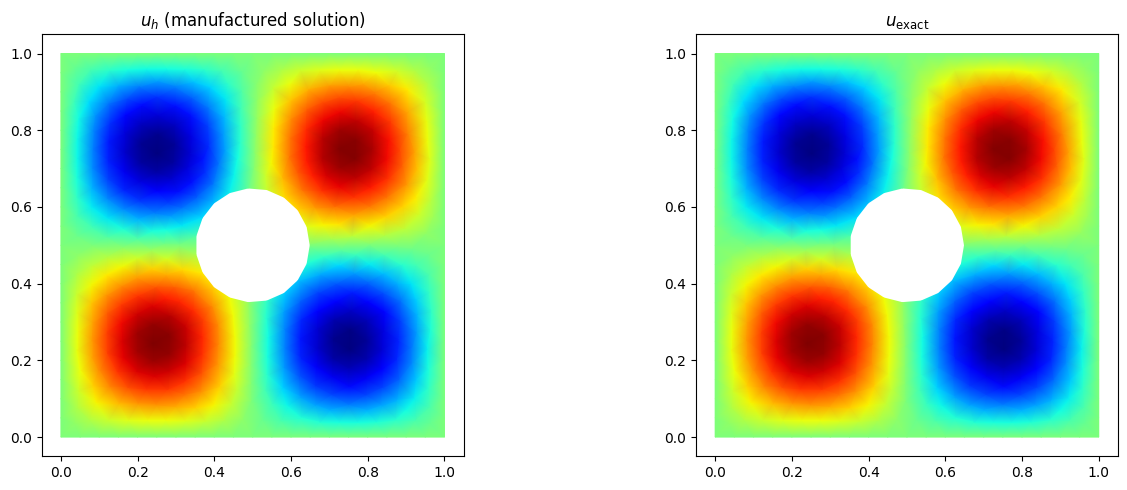

L2 error: 6.0786e-03
H1 error: 4.5393e-01


In [14]:
# Sanity check: visualize your manufactured solution result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fem_plot(mesh, u_h, ax=axes[0], shading='gouraud')
axes[0].set_title(r'$u_h$ (manufactured solution)')
axes[0].set_aspect('equal')

# Plot the exact solution for comparison
u_ex_nodal = u_exact(mesh.p[0], mesh.p[1])
fem_plot(mesh, u_ex_nodal, ax=axes[1], shading='gouraud')
axes[1].set_title(r'$u_{\mathrm{exact}}$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Print a quick error check
L2, H1 = compute_errors(basis, u_h, u_exact, du_exact_dx, du_exact_dy)
print(f"L2 error: {L2:.4e}")
print(f"H1 error: {H1:.4e}")

### TODO 4: Convergence Loop

Run the full solve pipeline at several mesh resolutions and record the errors.

**Steps for each `h_max`:**
1. Generate mesh: `m = make_mesh(h_max=...)`
2. Build basis: `ib = Basis(m, ElementTriP1())`
3. Assemble: `K = stiffness.assemble(ib)`, `b = manufactured_load.assemble(ib)`
4. Apply non-homogeneous Dirichlet BCs (same pattern as TODO 3, but use `m` and `ib`)
5. Solve
6. Compute errors: `L2, H1 = compute_errors(ib, u_h, u_exact, du_exact_dx, du_exact_dy)`
7. Record the **effective mesh size**: `m.param()` returns the maximum element diameter

In [15]:
hs_target = [0.15, 0.08, 0.04, 0.02]
hs_actual = []
L2_errors = []
H1_errors = []

# Print table header for Homework 4
print(f"{'h_max':>8} | {'h_eff':>8} | {'Nodes':>7} | {'L2 Error':>12} | {'H1 Error':>12}")
print("-" * 59)

for h_max in hs_target:
    # Generate mesh and basis
    m = make_mesh(h_max=h_max)
    ib = Basis(m, ElementTriP1())

    # Assemble system
    K = stiffness.assemble(ib)
    b = manufactured_load.assemble(ib)

    # Apply non-homogeneous Dirichlet BCs and solve
    bnd = m.boundary_nodes()
    x_bnd = m.p[0, bnd]
    y_bnd = m.p[1, bnd]

    u_D = np.zeros(ib.N)
    u_D[bnd] = u_exact(x_bnd, y_bnd)

    u_h = solve(*condense(K, b, x=u_D, D=bnd))

    # Compute errors and record
    L2, H1 = compute_errors(ib, u_h, u_exact, du_exact_dx, du_exact_dy)
    hs_actual.append(m.param())
    L2_errors.append(L2)
    H1_errors.append(H1)

    # Formatted row for your Homework 4 table
    print(f"{h_max:8.3f} | {m.param():8.4f} | {m.p.shape[1]:7d} | {L2:12.4e} | {H1:12.4e}")

hs_actual = np.array(hs_actual)
L2_errors = np.array(L2_errors)
H1_errors = np.array(H1_errors)

   h_max |    h_eff |   Nodes |     L2 Error |     H1 Error
-----------------------------------------------------------
   0.150 |   0.1682 |      92 |   3.9866e-02 |   1.1613e+00
   0.080 |   0.0985 |     227 |   1.4881e-02 |   7.0943e-01
   0.040 |   0.0535 |     778 |   3.9244e-03 |   3.6426e-01


   0.020 |   0.0272 |    2895 |   9.8330e-04 |   1.8332e-01


### TODO 5: Plot Convergence Rates

Create a log-log plot of the errors vs. effective mesh size $h$. Add reference lines for $O(h^2)$ and $O(h)$ to verify theoretical rates.

**Syntax reminder:**
```python
plt.loglog(hs_actual, L2_errors, 'o-', label=r'$L^2$ error')

# Reference line: c * h^p passing through the first data point
ref_h2 = L2_errors[0] * (hs_actual / hs_actual[0])**2
plt.loglog(hs_actual, ref_h2, 'k--', label=r'$O(h^2)$')
```

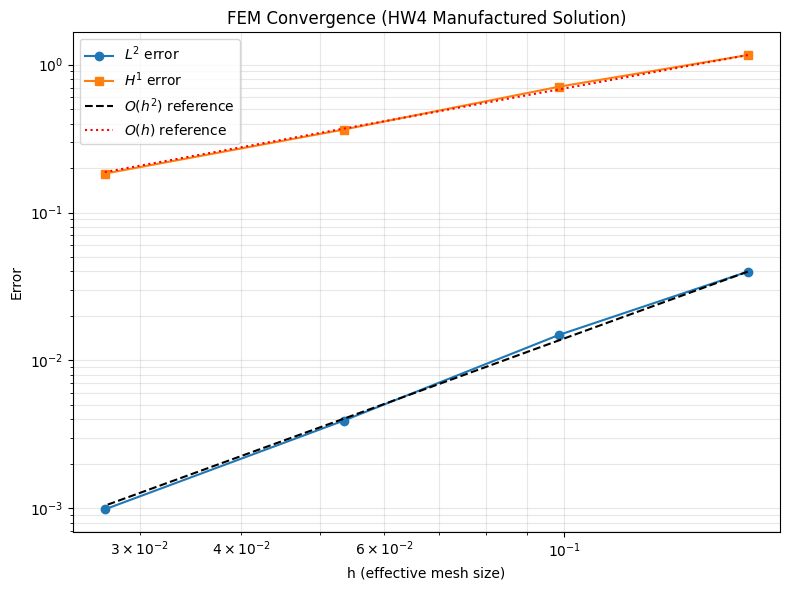


Convergence rates (successive ratios):
  h: 0.1682 -> 0.0985  L2 rate: 1.84  H1 rate: 0.92
  h: 0.0985 -> 0.0535  L2 rate: 2.19  H1 rate: 1.09
  h: 0.0535 -> 0.0272  L2 rate: 2.04  H1 rate: 1.01


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot errors vs h on log-log scale
ax.loglog(hs_actual, L2_errors, 'o-', label=r'$L^2$ error')
ax.loglog(hs_actual, H1_errors, 's-', label=r'$H^1$ error')

# Add O(h^2) and O(h) reference lines
ref_h2 = L2_errors[0] * (hs_actual / hs_actual[0])**2
ref_h1 = H1_errors[0] * (hs_actual / hs_actual[0])**1

ax.loglog(hs_actual, ref_h2, 'k--', label=r'$O(h^2)$ reference')
ax.loglog(hs_actual, ref_h1, 'r:', label=r'$O(h)$ reference')

ax.set_xlabel('h (effective mesh size)')
ax.set_ylabel('Error')
ax.set_title('FEM Convergence (HW4 Manufactured Solution)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConvergence rates (successive ratios):")
for i in range(1, len(hs_actual)):
    L2_rate = np.log(L2_errors[i] / L2_errors[i-1]) / np.log(hs_actual[i] / hs_actual[i-1])
    H1_rate = np.log(H1_errors[i] / H1_errors[i-1]) / np.log(hs_actual[i] / hs_actual[i-1])
    print(f"  h: {hs_actual[i-1]:.4f} -> {hs_actual[i]:.4f}  "
          f"L2 rate: {L2_rate:.2f}  H1 rate: {H1_rate:.2f}")

**Check your results:** You should see $L^2$ rates close to 2.0 and $H^1$ rates close to 1.0, confirming the theoretical estimates from Lecture 15.

---

## 8. Bonus Exercises

If you finish early, try one of these extensions:

**A. Higher-order elements** — Replace `ElementTriP1()` with `ElementTriP2()` (quadratic elements) and re-run the convergence study. What rates do you observe? (Theory predicts $O(h^3)$ in $L^2$, $O(h^2)$ in $H^1$.)

**B. Different geometry** — Modify `make_mesh` to create an L-shaped domain:
```python
with pygmsh.occ.Geometry() as geom:
    geom.characteristic_length_max = h_max
    big = geom.add_rectangle([0, 0, 0], 1.0, 1.0)
    cut = geom.add_rectangle([0.5, 0.5, 0], 0.5, 0.5)
    geom.boolean_difference(big, cut)
    msh = geom.generate_mesh(dim=2)
```
Does the L-shaped domain's re-entrant corner affect convergence rates?

**C. Non-homogeneous boundary on the hole** — Instead of matching $u_{\text{exact}}$, try setting $u = 1$ on the inner circle and $u = 0$ on the outer square (models a heat source at the hole). To select only the inner boundary, use:
```python
inner = mesh.facets_satisfying(
    lambda x: (x[0]-0.5)**2 + (x[1]-0.5)**2 < 0.2**2
)
inner_dofs = mesh.nodes_satisfying(
    lambda x: (x[0]-0.5)**2 + (x[1]-0.5)**2 < 0.2**2
)
```

In [17]:
hs_target = [0.15, 0.08, 0.04, 0.02]
hs_actual = []
L2_errors_P2 = []
H1_errors_P2 = []

for h_max in hs_target:
    m = make_mesh(h_max=h_max)
    # ---------------------------------------------------------
    # THE ONLY CHANGE: Use P2 elements instead of P1
    # ---------------------------------------------------------
    ib = Basis(m, ElementTriP2())

    K = stiffness.assemble(ib)
    b = manufactured_load.assemble(ib)

    bnd = m.boundary_nodes()
    x_bnd = m.p[0, bnd]
    y_bnd = m.p[1, bnd]

    u_D = np.zeros(ib.N)
    u_D[bnd] = u_exact(x_bnd, y_bnd)

    u_h = solve(*condense(K, b, x=u_D, D=bnd))

    L2, H1 = compute_errors(ib, u_h, u_exact, du_exact_dx, du_exact_dy)
    hs_actual.append(m.param())
    L2_errors_P2.append(L2)
    H1_errors_P2.append(H1)

    print(f"h_max={h_max:.3f} | L2={L2:.4e} | H1={H1:.4e}")

h_max=0.150 | L2=1.1618e-01 | H1=1.7599e+00
h_max=0.080 | L2=7.0121e-02 | H1=1.3867e+00


h_max=0.040 | L2=3.8068e-02 | H1=1.0307e+00


h_max=0.020 | L2=1.9292e-02 | H1=7.3581e-01


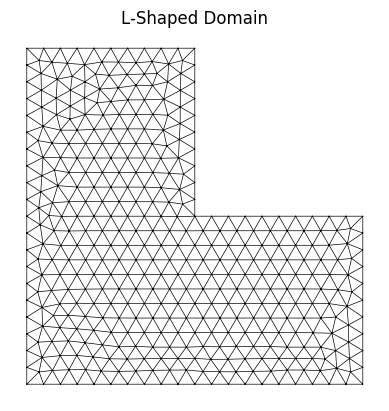

In [18]:
def make_mesh_L_shape(h_max=0.05):
    """Generate a triangular mesh of an L-shaped domain."""
    with pygmsh.occ.Geometry() as geom:
        geom.characteristic_length_max = h_max
        big = geom.add_rectangle([0.0, 0.0, 0.0], 1.0, 1.0)
        # Cut out the top right quadrant
        cut = geom.add_rectangle([0.5, 0.5, 0.0], 0.5, 0.5)
        geom.boolean_difference(big, cut)
        msh = geom.generate_mesh(dim=2)

    return MeshTri(
        msh.points[:, :2].T,
        msh.cells_dict['triangle'].T
    )

# Visualize it
m_L = make_mesh_L_shape(0.05)
fem_draw(m_L)
plt.title("L-Shaped Domain")
plt.show()

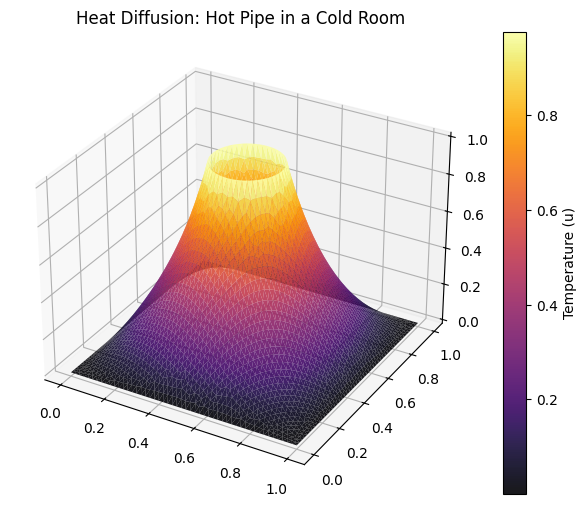

In [19]:
# 1. Setup Mesh and Basis
m = make_mesh(0.02)
ib = Basis(m, ElementTriP1())

# 2. Define a zero load (Laplace equation, f=0)
@LinearForm
def zero_load(v, w):
    return 0.0 * v

# Assemble the system
K = stiffness.assemble(ib)
b = zero_load.assemble(ib)

# 3. Identify different boundaries
all_bnd_dofs = m.boundary_nodes()

# Find DOFs strictly on the inner hole
inner_dofs = m.nodes_satisfying(
    lambda x: (x[0]-0.5)**2 + (x[1]-0.5)**2 < 0.16**2  # slightly larger than 0.15^2 to catch floating point
)

# Outer DOFs are just the total boundary minus the inner boundary
# (Using numpy set operations)
outer_dofs = np.setdiff1d(all_bnd_dofs, inner_dofs)

# 4. Build Dirichlet Vector
u_D = np.zeros(ib.N)
u_D[inner_dofs] = 1.0  # Hot pipe!
u_D[outer_dofs] = 0.0  # Cold walls!

# 5. Solve the system
u_h = solve(*condense(K, b, x=u_D, D=all_bnd_dofs))

# 6. Visualize the physical heat diffusion
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
tri = Triangulation(m.p[0], m.p[1], m.t.T)
surf = ax.plot_trisurf(tri, u_h, cmap='inferno', edgecolor='none', alpha=0.9)
fig.colorbar(surf, label='Temperature (u)')
ax.set_title("Heat Diffusion: Hot Pipe in a Cold Room")
plt.show()

# Acknowledgement
I have used AI only for putting comments in the code and make it easier for me to understand when I come back later. All my work is my own